# 6-fourier — validation package
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gamayos/finite-ring-space/blob/main/src/6-fourier/6-fourier-main.ipynb)

**Paper.** *Scale-Shift and Fractional Fourier Transform as Rotations over Finite Holographic Substrate* (Akhtman, 2026), `6-fourier` of the FRC corpus.
**Package.** `finite-ring-space/src/6-fourier` — five block scripts driven by this notebook, 36 checks. The paper carries no predicate
ledger of its own, so every cell below names the labelled statements it decides by their `\label` as printed in the paper (`Theorem`,
`Lemma`, `Proposition`, `Remark`, `Corollary`, `Example`, the one `Conjecture`, Table `tab:checks`), and gives the master-ledger row of the
corpus a check witnesses (`00:C2` scale-shift duality and the fractional Fourier cycle, `00:C14` the quarter-turn as the odd member of the
±√−1 pair, `00:C7` the conjugate reframing on the transform layer). The package regenerates the paper's one numerical figure
(`figures/entropy-cycle-f13`); the framed complex-plane rendering `f13-C` is a drawing, not a computation, and its generator is kept as is.

**Kinds.** `EXACT` checks are integer-pinned computations in F_p (a pass is a proof on the tested instances); `[approx]` checks compare a
floating-point observation with the value the paper states, to a stated tolerance — they occur in block E only, where the cyclotomic
observer readout of Definition `readout` realises the family on ℂⁿ. Blocks A–D are exact modular arithmetic throughout: the six shells of
Table `tab:checks`, p = 5, 13, 17, 29, 37, 41, with every primitive frame of each where a statement ranges over frames.

**Run.** Cell by cell, or *Runtime → Run all*; ≈ 10 s on Colab. The last cell writes `results.json` and fails loudly if any check fails.

In [1]:
# --- environment: clone the package if this notebook is not already running inside it (Colab). numpy and
# matplotlib are standard on Colab; nothing else is needed.
import os
if not os.path.exists("fcommon.py"):
    if not os.path.exists("finite-ring-space"):
        !git clone --filter=blob:none --sparse https://github.com/gamayos/finite-ring-space.git
        os.chdir("finite-ring-space")
        !git sparse-checkout set src/6-fourier
        os.chdir("src/6-fourier")
    else:
        os.chdir("finite-ring-space/src/6-fourier")
!pip install -q --disable-pip-version-check "numpy>=1.24" "matplotlib>=3.7"
print("working directory:", os.path.join(*os.getcwd().split(os.sep)[-3:]))

working directory: finite-ring-space/src/6-fourier


In [2]:
import os, importlib
os.environ["FOURIER_FIGDIR"] = "figures"
import fcommon
importlib.reload(fcommon)         # a fresh registry if the notebook is re-run
from IPython.display import Image, display
def show(name): display(Image(filename=f"figures/{name}.png"))
print("shells:", fcommon.SHELLS)

shells: [5, 13, 17, 29, 37, 41]


## Block A — the frame datum and the shell Fourier operator  (`a_shell.py`, EXACT; master ledger **00:C2**, **00:C14**)
The framed shell F_p(t; 0, 1, g): p = 4κ+1, g the generator of Table `tab:checks`, the oriented quarter-turn i = −g^κ, π = 2κ, e = g^i; the
shell Fourier matrix W_{kj} = g^{jk} and its normalisation F = iW.

| id | paper statement | predicate |
|---|---|---|
| A1 | §3 shell data (`it-def`, `capacity`), Table `tab:checks` | p = 4κ+1, g the smallest primitive root, i = −g^κ = g^{−κ}, i² ≡ −1, π = 2κ, 2π ≡ −1, g^π ≡ −1, −π ≡ 2⁻¹, e = g^i; the table's (κ, g, i) on all six shells |
| A2 | §3 (the Euler identity); **00:C14** | e^{iπ} = g^{2κ(i mod 2)} ≡ −1 exactly when the quarter-turn residue is odd; the conjugate reframing (g, i) ↦ (g⁻¹, −i) toggles the parity, so exactly one member of each conjugate pair carries e^{iπ} ≡ −1 — every primitive frame of the six shells; anchor F_13: i = 5, 6^{iπ} ≡ −1 |
| A3 | Remark `gt-covariance` | g' = g^u: the quarter-turn flips only on u ≡ 3 (mod 4); e' = g^{ui} ≠ e iff i(u−1) ≢ 0 (mod 4κ); p = 13, u = 5: e' = 2 ≠ 6 |
| A4 | Lemma `W-square`, Proposition `F-cycle`, Table `tab:checks`; **00:C2** | W² = −J, (iW)² = J, (iW)⁴ = I on the six shells |
| A5 | Remark `unitary-norm` | the square roots of 1/n ≡ −1 in F_p are exactly ±i: (cW)² = J iff c = ±i |
| A6 | Lemma `JF-decomp` | WJ = JW, FJ = JF; dim V⁺ = 2κ+1, dim V⁻ = 2κ−1 |

In [3]:
import a_shell; a_shell.run()

block A — the frame datum and the shell Fourier operator
  [PASS] A1   EXACT   [§3 shell data (eq:it-def, rem:capacity), tab:checks] p = 4κ+1, g the smallest primitive root, i = −g^κ = g^{−κ}, i² ≡ −1, π = 2κ, 2π ≡ −1, g^π ≡ −1, −π ≡ 2⁻¹, e = g^i; Table tab:checks (κ, g, i)  --  F_5(κ=1, g=2, i=3, e=3); F_13(κ=3, g=2, i=5, e=6); F_17(κ=4, g=3, i=4, e=13); F_29(κ=7, g=2, i=17, e=21); F_37(κ=9, g=2, i=6, e=27); F_41(κ=10, g=6, i=9, e=19)
  [PASS] A2   EXACT   [§3 Euler identity on the odd member; 00:C14] e^{iπ} = g^{2κ(i mod 2)} ≡ −1 exactly on the odd quarter-turn; the conjugate reframing toggles it, one member of each pair carries it  --  54 primitive frames of p ∈ [5, 13, 17, 29, 37, 41], 27 carry e^{iπ} ≡ −1 (one per conjugate pair); F_13(t;0,1,2): i = 5, e = 6, 6^{30} = 6^{6} ≡ −1
  [PASS] A3   EXACT   [rem:gt-covariance] g' = g^u: the quarter-turn flips only on u ≡ 3 (mod 4); e' = g^{ui} ≠ e iff i(u−1) ≢ 0 (mod 4κ); at p = 13, u = 5: e' = 2 ≠ 6  --  every unit u of Z_{4κ} on the si

## Block B — the fractional family F^[s] = Σ_ℓ g^{−ℓs} Π_ℓ  (`b_fractional.py`, EXACT; **00:C2**, **00:C7**)
Definition `FRC-FrFT-def`: the projectors Π_ℓ = ¼ Σ_r i^{−ℓr} F^r and the principal framed character lift.

| id | paper statement | predicate |
|---|---|---|
| B1 | Lemma `projectors` | Π_ℓ² = Π_ℓ, Π_ℓ Π_m = 0, Σ Π_ℓ = I, F Π_ℓ = i^ℓ Π_ℓ |
| B2 | Theorem `FRC-FrFT` (`additivity`); **00:C2** | F^[s+r] = F^[s] F^[r] on every pair (s, r) ∈ Z_{4κ}² — 4096 pairs |
| B3 | Theorem `FRC-FrFT` (`cardinal-FrFT`); **00:C2** | F^[0] = I, F^[κ] = F, F^[2κ] = J, F^[3κ] = F⁻¹, F^[4κ] = I; (F^[1])^κ = F |
| B4 | Theorem `faithful` | s ↦ F^[s] injective on Z_{4κ}, p = 5 included |
| B5 | Lemma `multiplicity` | m_ℓ = rank Π_ℓ = dim ker(F − i^ℓ I); m_0+m_2 = 2κ+1, m_1+m_3 = 2κ−1; m_0, m_2 ≥ 1; m_1, m_3 ≥ 1 for κ ≥ 2; at p = 5 one odd projector vanishes |
| B6 | Remark `multiplicities` | p = 13: (3,3,4,2) with Tr F = 4 at g = 2, (4,2,3,3) with Tr F = 9 at g = 6; m ↦ um conjugates F(g) to F(g^{u²}) by a permutation |
| B7 | Theorem `multiplicity` | G = Σ g^{k²} = ε(1+i); the two patterns; ε(g⁻¹) = −ε(g); ε(g^u) = (κ/u) ε(g); classes equally populated; the 38 primitive frames of p ∈ {5,13,17,29,37} (and the 16 of p = 41); p = 5: (2,0,1,1) at g = 2, (1,1,2,0) at g = 3 |
| B8 | Theorem `multiplicity` (proof) | G G* = −2, G² = 2i, Tr F = iG, Tr F² = 2, Tr F³ = iG*, m_ℓ ≡ ¼ Σ_r i^{−ℓr} Tr F^r (mod p) |
| B9 | Remark `classification` | every exponent lift a_ℓ ≡ ℓ (mod 4) is additive with the cardinal skeleton; the chart g^5 at p = 29 (u² ≢ 1 mod 28) does not commute with F |
| B10 | Remark `gt-covariance`; **00:C7** (transform layer) | the conjugate frame (g⁻¹, −i) keeps the operator relations, cardinal values, additivity and faithfulness; its multiplicity tuple is the other pattern; exactly F' = −F⁻¹ and Π'_ℓ = Π_{ℓ+2} |

In [4]:
import b_fractional; b_fractional.run()

block B — the fractional family
  [PASS] B1   EXACT   [lem:projectors] Π_ℓ² = Π_ℓ, Π_ℓ Π_m = 0, Σ Π_ℓ = I, F Π_ℓ = i^ℓ Π_ℓ  --  p ∈ [5, 13, 17, 29, 37, 41]


  [PASS] B2   EXACT   [thm:FRC-FrFT (eq:additivity); 00:C2] F^[s+r] = F^[s] F^[r] on every pair (s, r) of Z_{4κ}  --  4096 pairs over p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] B3   EXACT   [thm:FRC-FrFT (eq:cardinal-FrFT); 00:C2] F^[0] = I, F^[κ] = F, F^[2κ] = J, F^[3κ] = F⁻¹, F^[4κ] = I; (F^[1])^κ = F  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] B4   EXACT   [thm:faithful] s ↦ F^[s] is injective on Z_{4κ}: the 4κ members are pairwise distinct (p = 5 included)  --  p ∈ [5, 13, 17, 29, 37, 41]


  [PASS] B5   EXACT   [lem:multiplicity] m_ℓ = rank Π_ℓ = dim ker(F − i^ℓ I); m_0+m_2 = 2κ+1, m_1+m_3 = 2κ−1; m_0, m_2 ≥ 1; m_1, m_3 ≥ 1 for κ ≥ 2; p = 5: one odd projector vanishes  --  p=5: (2, 0, 1, 1); p=13: (3, 3, 4, 2); p=17: (4, 4, 5, 3); p=29: (7, 7, 8, 6); p=37: (9, 9, 10, 8); p=41: (10, 10, 11, 9)
  [PASS] B6   EXACT   [rem:multiplicities] p = 13: g = 2 gives (3,3,4,2), Tr F = 4; g = 6 gives (4,2,3,3), Tr F = 9; m ↦ um carries F(g) to F(g^{u²}) by a permutation  --  54 relabellings over p ∈ [5, 13, 17, 29, 37, 41]


  [PASS] B7   EXACT   [thm:multiplicity] G = ε(1+i), the two patterns, ε(g⁻¹) = −ε(g), ε(g^u) = (κ/u) ε(g), classes equally populated; 38 frames of p ∈ {5,…,37} and 16 of p = 41; p = 5: (2,0,1,1) at g = 2, (1,1,2,0) at g = 3  --  p=5: 2 frames, ε=+1 on 1; p=13: 4 frames, ε=+1 on 2; p=17: 8 frames, ε=+1 on 4; p=29: 12 frames, ε=+1 on 6; p=37: 12 frames, ε=+1 on 6; p=41: 16 frames, ε=+1 on 8


  [PASS] B8   EXACT   [thm:multiplicity (proof: G G* = −2, G² = 2i, the traces)] G G* = −2, G² = 2i, Tr F = iG, Tr F² = 2, Tr F³ = iG*, m_ℓ ≡ ¼ Σ_r i^{−ℓr} Tr F^r (mod p)  --  every primitive frame of the six shells
  [PASS] B9   EXACT   [rem:classification] exponent lifts a_ℓ ≡ ℓ (mod 4) are additive with the cardinal skeleton (p = 13); the chart g^5 at p = 29 (u² ≢ 1 mod 28) does not commute with F  --  non-commuting at p = 29, u = 5: True; all charts with u² ≢ 1 (mod 4κ) on the six shells non-commuting: True (28 charts)
  [PASS] B10  EXACT   [rem:gt-covariance (registered objects invariant under the conjugate reframing); 00:C7] the conjugate frame (g⁻¹, −i) keeps the operator relations, cardinal values, additivity and faithfulness; its multiplicity tuple is the other pattern; F' = −F⁻¹, Π'_ℓ = Π_{ℓ+2}  --  p=5: (2, 0, 1, 1) ↦ (1, 1, 2, 0); p=13: (3, 3, 4, 2) ↦ (4, 2, 3, 3); p=17: (4, 4, 5, 3) ↦ (5, 3, 4, 4); p=29: (7, 7, 8, 6) ↦ (8, 6, 7, 7); p=37: (9, 9, 10, 8) ↦ (10, 8, 9, 9); p=4

## Block C — representation domains and the coordinate-side zoom  (`c_domains.py`, EXACT; **00:C2**)
Definition `domain`: B_s = F^[s] B_0; Definition `scale-map`: S_r(x) = g^r x on the meridians M_m = {a g^m : a ∈ I_p}.

| id | paper statement | predicate |
|---|---|---|
| C1 | Definition `domain` | every F^[s] has full rank; the eigenvalues g^{−ℓs} are nonzero |
| C2 | Corollary `distinct-domains` | the 4κ framed bases are pairwise distinct |
| C3 | Remark `ordered-bases` | F^[s+2κ] = F^[s] J: 4κ framed domains, exactly 2κ unordered measurement bases |
| C4 | Proposition `meridian-scale`; **00:C2** | S_r(M_m) = M_{m+r} on every (m, r), as ordered lists |
| C5 | Corollary `effective-step`, Remark `framed-rational` | consecutive entries of M_m differ by g^m; S_{r+(p−1)} = S_r |
| C6 | Example `zoom-13`, Theorem `zoom`, Remark `two-layers` | the printed ladder M_0 … M_3 at steps 1, 2, 4, 8; the no-wrap window w g^r < p (w = π = 6) holds for r ≤ 1, the listing wraps from M_2 |

In [5]:
import c_domains; c_domains.run()

block C — representation domains and the coordinate-side zoom


  [PASS] C1   EXACT   [def:domain] every F^[s] has full rank 4κ over F_p; the eigenvalues g^{−ℓs} are nonzero  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] C2   EXACT   [cor:distinct-domains] the 4κ framed bases B_s = F^[s] B_0 are pairwise distinct  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] C3   EXACT   [rem:ordered-bases] F^[s+2κ] = F^[s] J, so B_{s+2κ} = B_s as unordered bases: 4κ framed domains, exactly 2κ measurement bases  --  p=5: 4 framed, 2 unordered; p=13: 12 framed, 6 unordered; p=17: 16 framed, 8 unordered; p=29: 28 framed, 14 unordered; p=37: 36 framed, 18 unordered; p=41: 40 framed, 20 unordered
  [PASS] C4   EXACT   [prop:meridian-scale; 00:C2] S_r(M_m) = M_{m+r} on every (m, r), as ordered lists  --  4096 pairs over p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] C5   EXACT   [cor:effective-step, rem:framed-rational (S_{r+(p−1)} = S_r)] consecutive entries of M_m differ by the effective step g^m; S_{r+(p−1)} = S_r  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] C6   EXACT   [ex:zoom-13, thm:

## Block D — the Weil dictionary and the operator-level comparison  (`d_weil.py`, EXACT)
The rotation R_s = [[c_s, −d_s], [d_s, c_s]] with z_s = g^{−s}; the exponent shift σ and the modulation D_1 = diag(g^k) on V.

| id | paper statement | predicate |
|---|---|---|
| D1 | Lemma `Rs-rotation` | c_s² + d_s² = 1, det R_s = 1 |
| D2 | Proposition `rotation-isom` | R_{s+r} = R_s R_r, injective, \|SO(2, F_p)\| = p − 1: an isomorphism Z_{4κ} ≅ SO(2, F_p) |
| D3 | Theorem `Weil-equivalence`, Table `tab:checks` | R_0 = I, R_κ = [[0,−1],[1,0]], R_{2κ} = −I, R_{3κ} = w⁻¹; z_κ = i |
| D4 | Proposition `nogo` | σ has the 4κ simple eigenvalues F_p^×; F^[1] has at most four; ⟨σ⟩ and ⟨F^[1]⟩ not conjugate for κ ≥ 2 |
| D5 | Proposition `charsector` | E_1 ≠ 0 for κ ≥ 2; F^[s] = g^{−s} on E_1; F^[s] T_v = T_v S_{−s}; R_s (1,−i)ᵀ = g^{−s} (1,−i)ᵀ |
| D6 | Proposition `heisenberg`, eq. `conj-expansion` | F σ F⁻¹ = D_1, F D_1 F⁻¹ = σ⁻¹; F^r σ = σ_r F^r; F^[s] = Σ_r c_r(s) F^r with c_r(s) = ¼ Σ_ℓ (g^{rκ−s})^ℓ |
| D7 | Conjecture `monomial` (the sweep) | F^[s] σ F^[s]⁻¹ monomial exactly at the four cardinal indices, non-monomial at all 112 intermediate indices of p ∈ {13, 17, 29, 37, 41} |

In [6]:
import d_weil; d_weil.run()

block D — the Weil dictionary and the operator-level comparison
  [PASS] D1   EXACT   [lem:Rs-rotation] c_s² + d_s² = 1, det R_s = 1: R_s ∈ SO(2, F_p) for every s  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] D2   EXACT   [prop:rotation-isom] R_{s+r} = R_s R_r, s ↦ R_s injective, |SO(2, F_p)| = p−1 = 4κ: an isomorphism  --  p=5: |SO(2)|=4; p=13: |SO(2)|=12; p=17: |SO(2)|=16; p=29: |SO(2)|=28; p=37: |SO(2)|=36; p=41: |SO(2)|=40
  [PASS] D3   EXACT   [thm:Weil-equivalence (the cardinal matrices), tab:checks] R_0 = I, R_κ = [[0,−1],[1,0]] (Table tab:checks), R_{2κ} = −I, R_{3κ} = w⁻¹; z_κ = g^{−κ} = i  --  p ∈ [5, 13, 17, 29, 37, 41]


  [PASS] D4   EXACT   [prop:nogo] σ has the 4κ simple eigenvalues F_p^×; F^[1] has at most four; for κ ≥ 2 ⟨σ⟩ and ⟨F^[1]⟩ are not conjugate  --  p=5: σ has 4 simple eigenvalues, F^[1] has 3; p=13: σ has 12 simple eigenvalues, F^[1] has 4; p=17: σ has 16 simple eigenvalues, F^[1] has 4; p=29: σ has 28 simple eigenvalues, F^[1] has 4; p=37: σ has 36 simple eigenvalues, F^[1] has 4; p=41: σ has 40 simple eigenvalues, F^[1] has 4
  [PASS] D5   EXACT   [prop:charsector] E_1 ≠ 0 for κ ≥ 2; F^[s] = g^{−s} on E_1; F^[s] T_v = T_v S_{−s} on every x and s; R_s (1,−i)ᵀ = g^{−s} (1,−i)ᵀ  --  p=5: E_1 = 0 (κ = 1); p=13: dim E_1 = 3; p=17: dim E_1 = 4; p=29: dim E_1 = 7; p=37: dim E_1 = 9; p=41: dim E_1 = 10
  [PASS] D6   EXACT   [prop:heisenberg] F σ F⁻¹ = D_1, F D_1 F⁻¹ = σ⁻¹; F^r σ = σ_r F^r with (σ, D_1, σ⁻¹, D_1⁻¹); F^[s] = Σ_r c_r(s) F^r, c_r(s) = ¼ Σ_ℓ (g^{rκ−s})^ℓ  --  p ∈ [5, 13, 17, 29, 37, 41]
  [PASS] D7   EXACT   [conj:monomial (the 112-index sweep)] F^[s] σ F^[s]⁻¹ is monomial exactly

## Block E — the cyclotomic observer readout and the entropy cycle  (`e_entropy.py`, EXACT / [approx])
Definition `readout`: the readout algebra A = Z[1/4n, X, Y, Y⁻¹]/(Φ_n(X), Y² − n) with the continuum chart σ_C (X ↦ ζ_n, Y ↦ +√n) and the
framed reduction ρ (X ↦ g, Y ↦ −i); on ℂⁿ the family is the canonical DFT projector family, and the Born vector of F^[s] δ_j gives H(s).

| id | paper statement | predicate | kind |
|---|---|---|---|
| E1 | Definition `readout` | Ĝ² = 2n X^κ modulo Φ_n(X), exact integer polynomial arithmetic; σ_C: (Σ ζ^{k²})² = 2n i; ρ: G² = 2i in F_p | EXACT |
| E2 | Proposition `entropy` | H(0) = H(2κ) = 0, H(κ) = H(3κ) = log n for every δ_j | [approx] |
| E3 | Proposition `entropy` | B_0, B_κ mutually unbiased; H_{B_0} + H_{B_κ} ≥ log n on random states, saturated by δ_j; the comb (δ_0+δ_6)/√2 at n = 12 gives log 2 + log 6 = log 12 | [approx] |
| E4 | Proposition `closedform` | the two-valued readout p_0 = 1 − (n−1)t_s/n, p_j = t_s/n, t_s = (2−ζ^{2s}−ζ^{−2s})/4 = sin²(πs/2κ); the closed-form H(s); strictly increasing on [0, κ]; period 2κ | [approx] |
| E5 | §9 table, Figure `entropy13` | p = 13: H(s)/log n = 0, .44, .91, 1, .91, .44, … ; regenerates `figures/entropy-cycle-f13` | [approx] |
| E6 | Remark `input-dep` | δ_1 at p = 13: H(1)/log n = 0.55 against 0.44; δ_j meets the odd projectors iff j ∉ {0, 2κ} | [approx] |
| E7 | Definition `readout` (the Galois twist) | X ↦ ζ^u relabels the δ_0 curve by s ↦ us on every unit u; the cardinal values of every δ_j are twist-invariant | [approx] |

block E — the cyclotomic observer readout
  [PASS] E1   EXACT   [def:readout (the reduction ρ, Ĝ² = 2nX^κ)] Ĝ² = 2n X^κ modulo Φ_n(X) (exact integer arithmetic); under σ_C: (Σ ζ^{k²})² = 2n i; under ρ: G² = 2i in F_p  --  n=4: deg Φ_n = 2; n=12: deg Φ_n = 4; n=16: deg Φ_n = 8; n=28: deg Φ_n = 12; n=36: deg Φ_n = 12; n=40: deg Φ_n = 16


  [PASS] E2   [approx] [prop:entropy (cardinal values)] H(0) = H(2κ) = 0, H(κ) = H(3κ) = log n for every δ_j  --  n ∈ [4, 12, 16, 28, 36, 40]
  [PASS] E3   [approx] [prop:entropy (mutually unbiased bases, Maassen–Uffink, the comb)] B_0, B_κ mutually unbiased (overlaps 1/n); H_{B_0} + H_{B_κ} ≥ log n on random states, saturated by δ_j; the comb (δ_0+δ_6)/√2 at n = 12: log 2 + log 6 = log 12  --  comb: H_0 = 0.6931 = log 2, H_κ = 1.7918 = log 6; 200 random states per shell
  [PASS] E4   [approx] [prop:closedform] F^[s] δ_0 has the two-valued readout p_0 = 1 − (n−1)t_s/n, p_j = t_s/n, t_s = (2−ζ^{2s}−ζ^{−2s})/4 = sin²(πs/2κ); H(s) the closed form, strictly increasing on [0, κ], period 2κ, strictly intermediate off the cardinal indices  --  n ∈ [4, 12, 16, 28, 36, 40]


  [PASS] E5   [approx] [§9 table H(s)/log n, fig:entropy13] p = 13: H(s)/log n = 0, .44, .91, 1, .91, .44, 0, .44, .91, 1, .91, .44 (fig:entropy13)  --  H/log n = 0.0000, 0.4378, 0.9134, 1.0000, 0.9134, 0.4378, 0.0000, 0.4378, 0.9134, 1.0000, 0.9134, 0.4378; wrote figures/entropy-cycle-f13.pdf/.png
  [PASS] E6   [approx] [rem:input-dep] δ_1 at p = 13: H(1)/log n = 0.55 against 0.44 for δ_0; δ_j meets the odd projectors exactly when j ∉ {0, 2κ}; δ_{2κ} reproduces the δ_0 curve  --  δ_1: H(1)/log n = 0.5499; δ_0: 0.4378


  [PASS] E7   [approx] [def:readout (the Galois twist relabels the intermediate curve)] X ↦ ζ^u relabels the δ_0 curve by s ↦ us on every unit u; the cardinal values of every δ_j are invariant under every twist  --  54 twists over the six shells


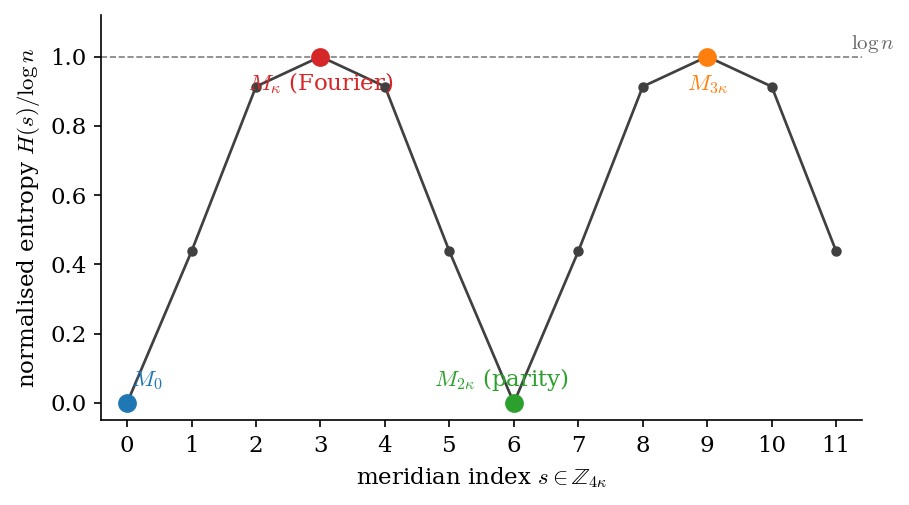

In [7]:
import e_entropy; e_entropy.run(); show('entropy-cycle-f13')

## Summary
Writes `results.json` (one record per check: id, the paper statement(s) decided and the master row witnessed, label, kind, PASS/FAIL, detail)
and raises if any check failed.

In [8]:
ok = fcommon.summary(write=True)
kinds = {}
for r in fcommon.RESULTS: kinds[r["kind"]] = kinds.get(r["kind"], 0) + 1
print("by kind:", ", ".join(f"{k} {v}" for k, v in sorted(kinds.items())))
failed = [r["id"] for r in fcommon.RESULTS if not r["ok"]]
assert ok, f"FAILED checks: {failed}"
print("all checks pass; figure in figures/, records in results.json")


SUMMARY: 36/36 checks passed
by kind: EXACT 30, [approx] 6
all checks pass; figure in figures/, records in results.json
